In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
#Loading the PIMA Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

df = pd.read_csv(url, names=columns)

In [4]:
#Analysing the dataset  by printing the first few data
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} column\n")
df.head(10)

Dataset Shape: 768 rows, 9 column



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
#Counting the zero values in the dataset
zero_counts = (df == 0).sum()

print(zero_counts)

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [7]:
#Replacing the zero values with NaN for the ML model

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)


In [8]:
#Verifying if the dataset has replaced the null values with
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
#Separating the features and target labels
X = df.drop(columns =["Outcome"])
y= df["Outcome"]

# Perform stratified split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 42, stratify = y
)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape:  (614, 8)
X_test shape:  (154, 8)


In [11]:
from sklearn.impute import SimpleImputer

In [12]:
#Imputing the missing values in train and test

#Initializing the imputer
imputer = SimpleImputer(strategy='median')

#Fitting and transforming on X_train only
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print(type(X_train_imputed))


<class 'numpy.ndarray'>


In [13]:
#Converting the imputed numpy arrays back to a pandas Dataframe

X_train_imputed = pd.DataFrame(X_train_imputed, columns = X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)


In [14]:
#Verifying if there are no remaining missing values
print("Missing values remaining in X_train: ", X_train_imputed.isnull().sum().sum())
print("Missing values remaining in X_test: ", X_test_imputed.isnull().sum().sum())

Missing values remaining in X_train:  0
Missing values remaining in X_test:  0


In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
#Initialize the standard scaler
scaler = StandardScaler()

#Fitting and transforming the scaler on the imputed data
X_train_scaled = scaler.fit_transform(X_train_imputed)

X_test_scaled = scaler.transform(X_test_imputed)

#Converting the scaled data into a pandas dataframe

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)



In [17]:
#Checking the summary statistics of the scaled dataframe
X_train_scaled.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.00,614.00,614.00,614.00,614.00,614.00,614.00,614.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.15,-2.19,-3.92,-2.48,-1.56,-2.09,-1.19,-1.05
25%,-0.85,-0.76,-0.66,-0.45,-0.22,-0.71,-0.70,-0.79
50%,-0.25,-0.16,-0.01,-0.00,-0.16,-0.01,-0.29,-0.37
75%,0.66,0.61,0.64,0.33,-0.10,0.59,0.49,0.65
max,3.98,2.58,4.07,7.87,7.70,5.08,5.61,4.03


In [18]:
X_train_imputed.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1.0,90.0,62.0,12.0,43.0,27.2,0.580,24.0
711,5.0,126.0,78.0,27.0,22.0,29.6,0.439,40.0
373,2.0,105.0,58.0,40.0,94.0,34.9,0.225,25.0
46,1.0,146.0,56.0,29.0,125.0,29.7,0.564,29.0
682,0.0,95.0,64.0,39.0,105.0,44.6,0.366,22.0


In [19]:
X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769694,0.310794,-0.792169
711,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417714,-0.116439,0.561034
373,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359576,-0.764862,-0.707594
46,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.403048,0.262314,-0.369293
682,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782163,-0.337630,-0.961320


In [20]:
from sklearn.model_selection import StratifiedKFold

In [21]:
#Implimenting a 5 fold cross validation

#Initializing the Kfold validator
skf = StratifiedKFold(n_splits= 5, shuffle= True, random_state = 42)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [23]:
#Initiallizing the logistic regression model
log_reg = LogisticRegression(random_state=42)

#Computing 5-fold cross validation scores
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train,
                            cv=skf, scoring="accuracy")


In [24]:
#Printing the results
print("Fold Scores:", cv_scores.round(4))
print("Mean Accuracy:", cv_scores.mean().round(4))


Fold Scores: [0.7886 0.7805 0.8211 0.7805 0.7623]
Mean Accuracy: 0.7866


In [25]:
#Computing the scores for recall and roc-auc

# Compute 5-fold cross-validation Recall
cv_recall = cross_val_score(log_reg, X_train_scaled, y_train, cv=skf, scoring='recall')

# Compute 5-fold cross-validation ROC-AUC
cv_auc = cross_val_score(log_reg, X_train_scaled, y_train, cv=skf, scoring='roc_auc')

print("Mean Recall:", cv_recall.mean().round(4))
print("Mean ROC-AUC:", cv_auc.mean().round(4))

Mean Recall: 0.5701
Mean ROC-AUC: 0.8428


In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
#Initiallize the random forest
r_forest = RandomForestClassifier(random_state=42)

#Computing cross validation for random forest
cv_accuracy_rf = cross_val_score(r_forest,X_train_scaled, y_train,
                            cv=skf, scoring="accuracy")

cv_recall_rf = cross_val_score(r_forest,X_train_scaled, y_train,
                            cv=skf, scoring="recall")

cv_auc_rf = cross_val_score(r_forest,X_train_scaled, y_train,
                            cv=skf, scoring="roc_auc")

In [28]:
#Printing the mean scores for random forest
print("Mean RF Accuracy:", cv_accuracy_rf.mean().round(4))
print("Mean RF Recall:", cv_recall_rf.mean().round(4))
print("Mean RF ROC-AUC:", cv_auc_rf.mean().round(4))

Mean RF Accuracy: 0.7638
Mean RF Recall: 0.5795
Mean RF ROC-AUC: 0.8183


In [29]:
from xgboost import XGBClassifier

In [30]:
#Initialize XGBoost
xgb = XGBClassifier(random_state = 42, eval_metric='logloss')

In [31]:
#Computing the cross validation scores for the XGBoost model
cv_accuracy_xgb = cross_val_score(xgb,X_train_scaled, y_train,
                            cv=skf, scoring="accuracy")

cv_recall_xgb = cross_val_score(xgb,X_train_scaled, y_train,
                            cv=skf, scoring="recall")

cv_auc_xgb = cross_val_score(xgb,X_train_scaled, y_train,
                            cv=skf, scoring="roc_auc")

In [32]:
#Print the mean xgb scores

print("Mean XGB Accuracy:", cv_accuracy_xgb.mean().round(4))
print("Mean XGB Recall:", cv_recall_xgb.mean().round(4))
print("Mean XGB ROC-AUC:", cv_auc_xgb.mean().round(4))

Mean XGB Accuracy: 0.741
Mean XGB Recall: 0.6028
Mean XGB ROC-AUC: 0.7817


##Class weights and Threshold tuning

### 1. Class weights

In [33]:
#Initializing a Logistic regression with balanced class weights

log_reg_balanced = LogisticRegression(class_weight="balanced", random_state=42)

In [34]:
#Computing the cross validation scores for the XGBoost model
cv_accuracy_lg_bal = cross_val_score(log_reg_balanced,X_train_scaled, y_train,
                            cv=skf, scoring="accuracy")

cv_recall_lg_bal = cross_val_score(log_reg_balanced,X_train_scaled, y_train,
                            cv=skf, scoring="recall")

cv_auc_lg_bal = cross_val_score(log_reg_balanced,X_train_scaled, y_train,
                            cv=skf, scoring="roc_auc")

In [35]:
#Print the mean log_reg_balanced scores

print("Mean log_reg_balanced Accuracy:", cv_accuracy_lg_bal.mean().round(4))
print("Mean log_reg_balanced Recall:", cv_recall_lg_bal.mean().round(4))
print("Mean log_reg_balanced ROC-AUC:", cv_auc_lg_bal.mean().round(4))

Mean log_reg_balanced Accuracy: 0.7622
Mean log_reg_balanced Recall: 0.701
Mean log_reg_balanced ROC-AUC: 0.8442


In [36]:
#Applying the balanced class weights to random forest and XGBoost

#Initializing the random forest with balanced class weights
rf_balanced = RandomForestClassifier(class_weight="balanced", random_state=42)

#Scaling weights for XGB
scaled_weights = (y_train == 0).sum() / (y_train == 1).sum()

#Initializing the XGB with scaled weights
xgb_balanced = XGBClassifier(scale_pos_weight = scaled_weights, random_state = 42)



In [37]:
#Computing cross validation for the balanced random forest and XGB with balanced weights
cv_accuracy_rf_balanced = cross_val_score(rf_balanced,X_train_scaled, y_train,
                            cv=skf, scoring="accuracy")

cv_recall_rf_balanced = cross_val_score(rf_balanced,X_train_scaled, y_train,
                            cv=skf, scoring="recall")

cv_auc_rf_balanced = cross_val_score(rf_balanced,X_train_scaled, y_train,
                            cv=skf, scoring="roc_auc")



cv_accuracy_xgb_balanced = cross_val_score(xgb_balanced,X_train_scaled, y_train,
                            cv=skf, scoring="accuracy")

cv_recall_xgb_balanced = cross_val_score(xgb_balanced,X_train_scaled, y_train,
                            cv=skf, scoring="recall")

cv_auc_xgb_balanced = cross_val_score(xgb_balanced,X_train_scaled, y_train,
                            cv=skf, scoring="roc_auc")

In [38]:
#Printing the means of the scores of the balanced tree models
print("Mean rf_balanced Accuracy:", cv_accuracy_rf_balanced.mean().round(4))
print("Mean rf_balanced Recall:", cv_recall_rf_balanced.mean().round(4))
print("Mean rf_balanced ROC-AUC:", cv_auc_rf_balanced.mean().round(4))

print("Mean xgb_balanced Accuracy:", cv_accuracy_xgb_balanced.mean().round(4))
print("Mean xgb_balanced Recall:", cv_recall_xgb_balanced.mean().round(4))
print("Mean xgb_balanced ROC-AUC:", cv_auc_xgb_balanced.mean().round(4))


Mean rf_balanced Accuracy: 0.7654
Mean rf_balanced Recall: 0.5794
Mean rf_balanced ROC-AUC: 0.8205
Mean xgb_balanced Accuracy: 0.7459
Mean xgb_balanced Recall: 0.6449
Mean xgb_balanced ROC-AUC: 0.7855


## Optimizing logistic regression

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
#Defining the parameter grid
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'solver':['liblinear', 'lbfgs', 'saga']}

#Initialize grid search
grid_search = GridSearchCV(estimator=LogisticRegression(class_weight='balanced', random_state=42),
                           param_grid=param_grid,
                           cv=skf,
                           scoring='roc_auc',
                           n_jobs=-1)

In [41]:
#Fitting the grid_search
grid_search.fit(X_train_scaled, y_train)

#Checking the best parameters
print("Best parameters:", grid_search.best_params_)

print("Best CV ROC-AUC Score: ", round(grid_search.best_score_, 4))

Best parameters: {'C': 0.1, 'solver': 'saga'}
Best CV ROC-AUC Score:  0.8452


### 3. Threshold tuning

In [42]:
from sklearn.model_selection import cross_val_predict

In [43]:
#Extracting the best estimating model
best_log_reg = grid_search.best_estimator_

#Getting the best probabilites for the positive class (Class 1 =  Diabetic)
y_probs = cross_val_predict(best_log_reg, X_train_scaled, y_train, cv = skf, method = 'predict_proba')[:,1]

In [44]:
#Printing the first 5 probability scores
print("First 5 Patient Risk Scores: ", y_probs[:5].round(4))

First 5 Patient Risk Scores:  [0.1008 0.4472 0.2538 0.4905 0.3149]


In [45]:
from sklearn.metrics import precision_recall_curve

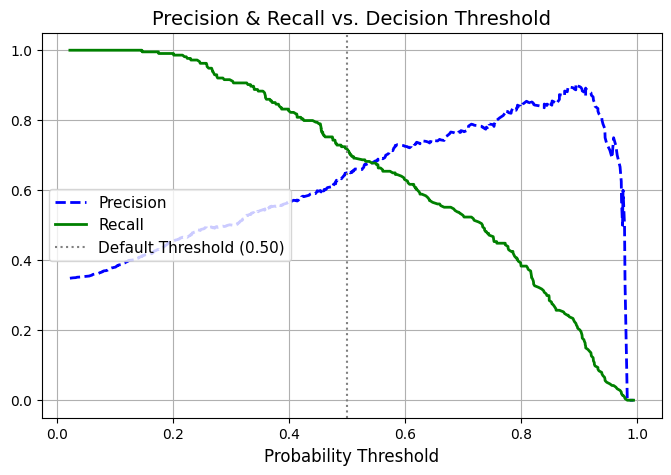

In [46]:
#Plotting the precision recall curve

#Calculating the precision, recall and thresholds across all probability cutoffs
precisions, recalls, thresholds = precision_recall_curve(y_train, y_probs)

#Plotting the precision and recall against the descision thresholds
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Probability Threshold", fontsize=12)
plt.title("Precision & Recall vs. Decision Threshold", fontsize=14)
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default Threshold (0.50)')
plt.grid(True)
plt.legend(loc="center left", fontsize=11)
plt.show()

### Evaluating a custom threshold

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [48]:
#Applying a custom probability threshold
custom_threshold = 0.35
y_pred_custom = (y_probs >= custom_threshold).astype(int)

#Printing the confustion matrix
print(f"Confusion matrix at Threshold {custom_threshold}")
print(confusion_matrix(y_train, y_pred_custom))

#Printig a classification report
print(f"Classification report at threshold {custom_threshold}")
print(classification_report(y_train, y_pred_custom, target_names=['Healthy (0)', 'Diabetic (1)']))

Confusion matrix at Threshold 0.35
[[241 159]
 [ 25 189]]
Classification report at threshold 0.35
              precision    recall  f1-score   support

 Healthy (0)       0.91      0.60      0.72       400
Diabetic (1)       0.54      0.88      0.67       214

    accuracy                           0.70       614
   macro avg       0.72      0.74      0.70       614
weighted avg       0.78      0.70      0.71       614



## Final Evaluation of the model

In [49]:
# 1. Get predicted probabilities for diabetic class (Class 1)
test_probs = best_log_reg.predict_proba(X_test_scaled)[:, 1]

# 2. Apply custom threshold (0.35)
test_preds = (test_probs >= 0.35).astype(int)

# 3. Print Test Metrics
print("=== FINAL TEST SET EVALUATION ===")
print("Test ROC-AUC Score:", round(roc_auc_score(y_test, test_probs), 4))
print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, test_preds))
print("\nTest Classification Report:")
print(classification_report(y_test, test_preds, target_names=['Healthy (0)', 'Diabetic (1)']))

=== FINAL TEST SET EVALUATION ===
Test ROC-AUC Score: 0.8104

Test Confusion Matrix:
[[60 40]
 [ 6 48]]

Test Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.91      0.60      0.72       100
Diabetic (1)       0.55      0.89      0.68        54

    accuracy                           0.70       154
   macro avg       0.73      0.74      0.70       154
weighted avg       0.78      0.70      0.71       154



### Feature Importance

In [50]:
#Extracting coefficients and calculating Odds Ratios
feature_names = X.columns
coefs = best_log_reg.coef_[0]
odds_ratios = np.exp(coefs)



In [51]:
# Create a clean DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs.round(4),
    'Odds Ratio': odds_ratios.round(4)
}).sort_values(by='Odds Ratio', ascending=False)

print("=== CLINICAL FEATURE IMPORTANCE ===")
print(feature_importance)

=== CLINICAL FEATURE IMPORTANCE ===
                    Feature  Coefficient  Odds Ratio
1                   Glucose       1.0233      2.7824
5                       BMI       0.5991      1.8205
0               Pregnancies       0.3204      1.3777
6  DiabetesPedigreeFunction       0.2556      1.2912
7                       Age       0.1892      1.2083
3             SkinThickness       0.0586      1.0603
2             BloodPressure       0.0172      1.0173
4                   Insulin       0.0164      1.0165


### Saving the prefitted scaler and Logistic regression model

In [52]:
import joblib

In [53]:
#Saving the prefitted scaler
joblib.dump(scaler, 'scaler.joblib')

#Saving the prefitted logistic regression model
joblib.dump(best_log_reg, 'model.joblib')

['model.joblib']

In [54]:
#Building an inference wrapper

class ClinicalPredictor:
  def __init__(self, scaler_path='scaler.joblib', model_path='model.joblib', threshold=0.35):
    self.scaler = joblib.load(scaler_path)
    self.model = joblib.load(model_path)
    self.threshold = threshold
    self.feature_names = [
        'Pregnancies', 'Glucose', 'BloodPressure',
        'SkinThickness', 'Insulin', 'BMI',
        'DiabetesPedigreeFunction', 'Age']

  def predict_patient_risk(self, patient_dict: dict) -> dict:
    """
    Accepts a dictionary of raw patient features, scales them,
    and evaluates risk against the 0.35 clinical threshold """

    #Convert patient dictionary to Dataframe matching to match training feature structure
    df_patient = pd.DataFrame([patient_dict])[self.feature_names]

    #Scaled features using the loaded pre-fitted scaler
    scaled_array = self.scaler.transform(df_patient)

    #Preserve feature names to prevent scikit-learn warning
    scaled_features = pd.DataFrame(scaled_array, columns=self.feature_names )

    #Calculate the probability score for the Diabetic class (Class 1)
    risk_probability = float(self.model.predict_proba(scaled_features)[:, 1][0])

    #Applying a custom decision threshold
    is_high_risk = risk_probability >= self.threshold


    return {
        "diabetic_risk_score": round(risk_probability, 4),
        "custom_threshold_applied": self.threshold,
        "high_risk_flag": int(is_high_risk),
        "clinical_recommendation": (
            "Flagged for immediate confirmatory diagnostic testing (HbA1c)."
            if is_high_risk else
            "Low risk detected; maintain standard periodic screening schedule."

        )
    }

In [55]:
#Testing the class clinical predictor with sample patients
predictor = ClinicalPredictor()

patient_high_risk = {
    'Pregnancies': 3,
    'Glucose': 168.0,
    'BloodPressure': 74.0,
    'SkinThickness': 32.0,
    'Insulin': 180.0,
    'BMI': 37.5,
    'DiabetesPedigreeFunction': 0.627,
    'Age': 42
}

patient_borderline = {
    'Pregnancies': 1,
    'Glucose': 118.0,
    'BloodPressure': 68.0,
    'SkinThickness': 20.0,
    'Insulin': 85.0,
    'BMI': 28.1,
    'DiabetesPedigreeFunction': 0.315,
    'Age': 26
}

print("PATIENT 1 (HIGH RISK)")
print(predictor.predict_patient_risk(patient_high_risk))

print("PATIENT 2 (BODERLINE)")
print(predictor.predict_patient_risk(patient_borderline))

PATIENT 1 (HIGH RISK)
{'diabetic_risk_score': 0.8798, 'custom_threshold_applied': 0.35, 'high_risk_flag': 1, 'clinical_recommendation': 'Flagged for immediate confirmatory diagnostic testing (HbA1c).'}
PATIENT 2 (BODERLINE)
{'diabetic_risk_score': 0.2074, 'custom_threshold_applied': 0.35, 'high_risk_flag': 0, 'clinical_recommendation': 'Low risk detected; maintain standard periodic screening schedule.'}


### Building a FastAPI for the clinical predictor

In [56]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field

In [57]:
#Pydantic schema (Data integrity guardrails)

class PatientData(BaseModel):
  Pregnancies: int = Field(..., ge=0, description="Number of times pregnant", examples=3)
  Glucose : float = Field(..., ge=0.0,description="Plasma glucose concentration (mg/dL)", examples=168.0)
  BloodPressure: float = Field(..., ge=0.0, description="Diastolic blood pressure (mm Hg)", examples=74.0)
  SkinThickness: float = Field(..., ge=0.0, description="Triceps skin fold thickness (mm)", examples=32.0)
  Insulin: float = Field(..., ge=0.0, description="2-Hour serum insulin (mu U/ml)", examples=180.0)
  BMI: float = Field(..., ge=0.0, description="Body mass index (weight in kg/(height in m)^2)", examples=37.5)
  DiabetesPedigreeFunction: float = Field(..., ge=0.0, description="Diabetes pedigree function score", examples=0.627)
  Age: int = Field(..., ge=0, description="Age in years", examples=42)


class PredictionResponse(BaseModel):
  diabetic_risk_score: float
  custom_threshold_applied: float
  high_risk_flag: int
  clinical_recommendation: str

In [58]:
#FastAPI setup
app = FastAPI(
    title="Clinical Diabetes Risk Assessment API",
    description = "Microservice for realtime diabetic risk scoring with custom clinical thresholding (0.35).",
    version = "1.0.0"
    )

#Initialize predictor instance on server startup
try:
  predictor = ClinicalPredictor()
except Exception as e:
  raise RuntimeError(f"Failed to load model artificats: {e}")

In [59]:
#API Endpoints
@app.get("/", tags=["Health Check"])
def health_check():
  """Health check endpoint to verify API operational status."""
  return{"status": "healthy", "service": "Clinical Diabetes Risk Assessment API"}


@app.post("/predict", response_model=PredictionResponse, tags =["Prediction"])
def predict_risk(patient: PatientData):
  """
  Accepts raw patient clinical parameters and returns a risk score,
  custom threshold binary flag, and actionable clinical recommendation.
  """
  try:
    patient_dict = patient.model_dump()
    result = predictor.predict_patient_risk(patient_dict)
    return result
  except Exception as e:
    raise HTTPException(status_code=500, detail=f"Prediction error: {str(e)}")


In [60]:
#Testing the API
# Step 1: Ensure httpx is installed (required by FastAPI TestClient)
!pip install -q httpx

from fastapi.testclient import TestClient
import json

# Initialize the virtual client connected to your 'app' instance
client = TestClient(app)

# ------------------------------------------------------------------
# TEST 1: Valid Patient Payload (Expects HTTP 200 OK)
# ------------------------------------------------------------------
valid_patient = {
    "Pregnancies": 3,
    "Glucose": 168.0,
    "BloodPressure": 74.0,
    "SkinThickness": 32.0,
    "Insulin": 180.0,
    "BMI": 37.5,
    "DiabetesPedigreeFunction": 0.627,
    "Age": 42
}

response_valid = client.post("/predict", json=valid_patient)

print(f"=== TEST 1: VALID INPUT ===")
print(f"HTTP Status Code: {response_valid.status_code}")
print(f"Response Body: {json.dumps(response_valid.json(), indent=2)}")

# ------------------------------------------------------------------
# TEST 2: Invalid Payload with Negative Glucose & BMI (Expects HTTP 422)
# ------------------------------------------------------------------
invalid_patient = {
    "Pregnancies": 3,
    "Glucose": -150.0,  # Invalid: violates ge=0.0
    "BloodPressure": 74.0,
    "SkinThickness": 32.0,
    "Insulin": 180.0,
    "BMI": -22.4,       # Invalid: violates ge=0.0
    "DiabetesPedigreeFunction": 0.627,
    "Age": 42
}

response_invalid = client.post("/predict", json=invalid_patient)

print(f"\n=== TEST 2: INVALID NEGATIVE INPUT ===")
print(f"HTTP Status Code: {response_invalid.status_code}")
print(f"Pydantic Validation Error Output:\n{json.dumps(response_invalid.json(), indent=2)}")

=== TEST 1: VALID INPUT ===
HTTP Status Code: 200
Response Body: {
  "diabetic_risk_score": 0.8798,
  "custom_threshold_applied": 0.35,
  "high_risk_flag": 1,
  "clinical_recommendation": "Flagged for immediate confirmatory diagnostic testing (HbA1c)."
}

=== TEST 2: INVALID NEGATIVE INPUT ===
HTTP Status Code: 422
Pydantic Validation Error Output:
{
  "detail": [
    {
      "type": "greater_than_equal",
      "loc": [
        "body",
        "Glucose"
      ],
      "msg": "Input should be greater than or equal to 0",
      "input": -150.0,
      "ctx": {
        "ge": 0.0
      }
    },
    {
      "type": "greater_than_equal",
      "loc": [
        "body",
        "BMI"
      ],
      "msg": "Input should be greater than or equal to 0",
      "input": -22.4,
      "ctx": {
        "ge": 0.0
      }
    }
  ]
}


# EXPORTING THE FILES AND MAKING A DOCKER FILE TO RUN THE MODEL LOCALLY


In [62]:
import joblib

# Save the pre-fitted scaler and tuned Logistic Regression model using your exact variable names
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(best_log_reg, 'model.joblib')

print("Model artifacts successfully saved to Colab disk!")

Model artifacts successfully saved to Colab disk!


In [63]:
%%writefile predictor.py
import joblib
import pandas as pd

class ClinicalPredictor:
    def __init__(self, scaler_path='scaler.joblib', model_path='model.joblib', threshold=0.35):
        self.scaler = joblib.load(scaler_path)
        self.model = joblib.load(model_path)
        self.threshold = threshold
        self.feature_names = [
            'Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age'
        ]

    def predict_patient_risk(self, patient_dict: dict) -> dict:
        df_patient = pd.DataFrame([patient_dict])[self.feature_names]
        scaled_array = self.scaler.transform(df_patient)
        scaled_features = pd.DataFrame(scaled_array, columns=self.feature_names)

        risk_probability = float(self.model.predict_proba(scaled_features)[:, 1][0])
        is_high_risk = risk_probability >= self.threshold

        return {
            "diabetic_risk_score": round(risk_probability, 4),
            "custom_threshold_applied": self.threshold,
            "high_risk_flag": int(is_high_risk),
            "clinical_recommendation": (
                "Flagged for immediate confirmatory diagnostic testing (HbA1c)."
                if is_high_risk else
                "Low risk detected; maintain standard periodic screening schedule."
            )
        }

Writing predictor.py


In [64]:
%%writefile app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from predictor import ClinicalPredictor

class PatientData(BaseModel):
    Pregnancies: int = Field(..., ge=0, description="Number of times pregnant", examples=[3])
    Glucose: float = Field(..., ge=0.0, description="Plasma glucose concentration (mg/dL)", examples=[168.0])
    BloodPressure: float = Field(..., ge=0.0, description="Diastolic blood pressure (mm Hg)", examples=[74.0])
    SkinThickness: float = Field(..., ge=0.0, description="Triceps skin fold thickness (mm)", examples=[32.0])
    Insulin: float = Field(..., ge=0.0, description="2-Hour serum insulin (mu U/ml)", examples=[180.0])
    BMI: float = Field(..., ge=0.0, description="Body mass index", examples=[37.5])
    DiabetesPedigreeFunction: float = Field(..., ge=0.0, description="Diabetes pedigree function score", examples=[0.627])
    Age: int = Field(..., ge=0, description="Age in years", examples=[42])

class PredictionResponse(BaseModel):
    diabetic_risk_score: float
    custom_threshold_applied: float
    high_risk_flag: int
    clinical_recommendation: str

app = FastAPI(
    title="Clinical Diabetes Risk Assessment API",
    description="Microservice for real-time diabetic risk scoring with custom clinical thresholding (0.35).",
    version="1.0.0"
)

try:
    predictor = ClinicalPredictor()
except Exception as e:
    raise RuntimeError(f"Failed to load model artifacts: {e}")

@app.get("/", tags=["Health Check"])
def health_check():
    return {"status": "healthy", "service": "Clinical Diabetes Risk Assessment API"}

@app.post("/predict", response_model=PredictionResponse, tags=["Prediction"])
def predict_risk(patient: PatientData):
    try:
        patient_dict = patient.model_dump()
        return predictor.predict_patient_risk(patient_dict)
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Prediction error: {str(e)}")

Writing app.py


### Requirements file

In [65]:
%%writefile requirements.txt
fastapi>=0.100.0
uvicorn[standard]>=0.22.0
pydantic>=2.0.0
joblib>=1.2.0
pandas>=2.0.0
scikit-learn>=1.2.0

Writing requirements.txt


### Docker file

In [66]:
%%writefile Dockerfile
FROM python:3.10-slim

WORKDIR /app

ENV PYTHONDONTWRITEBYTECODE=1 \
    PYTHONUNBUFFERED=1

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py predictor.py scaler.joblib model.joblib ./

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile


In [67]:
import zipfile
from google.colab import files

files_to_zip = [
    'app.py',
    'predictor.py',
    'requirements.txt',
    'Dockerfile',
    'scaler.joblib',
    'model.joblib'
]

with zipfile.ZipFile('clinical_diabetes_api.zip', 'w') as zipf:
    for file_name in files_to_zip:
        zipf.write(file_name)

print("Packaging complete! Triggering browser download...")
files.download('clinical_diabetes_api.zip')

Packaging complete! Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>